# 🚗 التنبؤ بشراء سيارة كهربائية (EV) باستخدام LDA
مشروع Supervised Learning لتصنيف ثنائي: هل سيشتري العميل سيارة كهربائية أم لا (`Will_Buy_EV`)، باستخدام خوارزمية **Linear Discriminant Analysis (LDA)**.

## 🧱 الخطوة 1: تهيئة البيئة واستيراد الأدوات (Setup & Imports)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, ConfusionMatrixDisplay

def seed_everything(seed=42):
    np.random.seed(seed)

seed_everything(42)
sns.set_style("darkgrid")


## 📊 الخطوة 2: تحميل البيانات واستكشافها الأولي (Data Ingestion & Inspection)

In [2]:
train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')

print("Train shape:", train.shape)
print("Test shape:", test.shape)
train.head()


Train shape: (668665, 15)
Test shape: (286571, 14)


,id,Age,Annual_Income_USD,Daily_Commute_km,Number_of_Cars_Owned,Charging_Stations_Near_Home,Charging_Stations_Near_Work,Environmental_Concern_Level,Gender,City_Type,Current_Car_Type,Home_Charging_Possible,Subsidy_Available,Range_Anxiety_Level,Will_Buy_EV
0,0,66,92887.0,23.4,2,3,7,1.0,Male,Suburban,Sedan,Yes,No,Low,No
1,1,38,30000.0,5.0,1,2,2,4.0,Male,Rural,SUV,Yes,No,Low,No
2,2,26,94389.0,36.8,1,8,15,5.0,Female,Urban,Sedan,No,Yes,Low,Yes
3,3,66,73580.0,23.7,2,6,9,3.0,Male,Suburban,Hatchback,Yes,No,Low,No
4,4,54,57898.0,50.8,1,2,3,3.0,Male,Suburban,Hatchback,Yes,No,Low,No


In [3]:
train.info()


<class 'pandas.DataFrame'>
RangeIndex: 668665 entries, 0 to 668664
Data columns (total 15 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   id                           668665 non-null  int64  
 1   Age                          668665 non-null  int64  
 2   Annual_Income_USD            668665 non-null  float64
 3   Daily_Commute_km             668665 non-null  float64
 4   Number_of_Cars_Owned         668665 non-null  int64  
 5   Charging_Stations_Near_Home  668665 non-null  int64  
 6   Charging_Stations_Near_Work  668665 non-null  int64  
 7   Environmental_Concern_Level  668665 non-null  float64
 8   Gender                       668665 non-null  str    
 9   City_Type                    668665 non-null  str    
 10  Current_Car_Type             668665 non-null  str    
 11  Home_Charging_Possible       668665 non-null  str    
 12  Subsidy_Available            668665 non-null  str    
 13  Range_Anxi

## 🧼 الخطوة 3: تنظيف البيانات وإعدادها (Data Cleaning & Preprocessing)
- التأكد من عدم وجود قيم مفقودة.
- فصل الميزات (X) عن الهدف (y).
- تحويل الأعمدة النصية (Categorical) إلى أرقام عبر Label Encoding.

In [4]:
print("Missing values per column:\n", train.isnull().sum())


Missing values per column:
 id                             0
Age                            0
Annual_Income_USD              0
Daily_Commute_km               0
Number_of_Cars_Owned           0
Charging_Stations_Near_Home    0
Charging_Stations_Near_Work    0
Environmental_Concern_Level    0
Gender                         0
City_Type                      0
Current_Car_Type               0
Home_Charging_Possible         0
Subsidy_Available              0
Range_Anxiety_Level            0
Will_Buy_EV                    0
dtype: int64


In [5]:
cat_cols = ['Gender', 'City_Type', 'Current_Car_Type', 'Home_Charging_Possible',
            'Subsidy_Available', 'Range_Anxiety_Level']
num_cols = ['Age', 'Annual_Income_USD', 'Daily_Commute_km', 'Number_of_Cars_Owned',
            'Charging_Stations_Near_Home', 'Charging_Stations_Near_Work',
            'Environmental_Concern_Level']

le_target = LabelEncoder()
y = le_target.fit_transform(train['Will_Buy_EV'])  # No=0, Yes=1

X = train.drop(columns=['id', 'Will_Buy_EV']).copy()
X_test_final = test.drop(columns=['id']).copy()

encoders = {}
for c in cat_cols:
    le = LabelEncoder()
    combined = pd.concat([X[c], X_test_final[c]], axis=0)
    le.fit(combined)
    X[c] = le.transform(X[c])
    X_test_final[c] = le.transform(X_test_final[c])
    encoders[c] = le

X.head()


,Age,Annual_Income_USD,Daily_Commute_km,Number_of_Cars_Owned,Charging_Stations_Near_Home,Charging_Stations_Near_Work,Environmental_Concern_Level,Gender,City_Type,Current_Car_Type,Home_Charging_Possible,Subsidy_Available,Range_Anxiety_Level
0,66,92887.0,23.4,2,3,7,1.0,1,1,2,1,0,1
1,38,30000.0,5.0,1,2,2,4.0,1,0,1,1,0,1
2,26,94389.0,36.8,1,8,15,5.0,0,2,2,0,1,1
3,66,73580.0,23.7,2,6,9,3.0,1,1,0,1,0,1
4,54,57898.0,50.8,1,2,3,3.0,1,1,0,1,0,1


## 📈 الخطوة 4: التحليل الاستكشافي والتأكد من شروط LDA (EDA)
- فحص التوزيع الطبيعي (Gaussian) للميزات الرقمية.
- التأكد من توازن الفئات في الهدف.

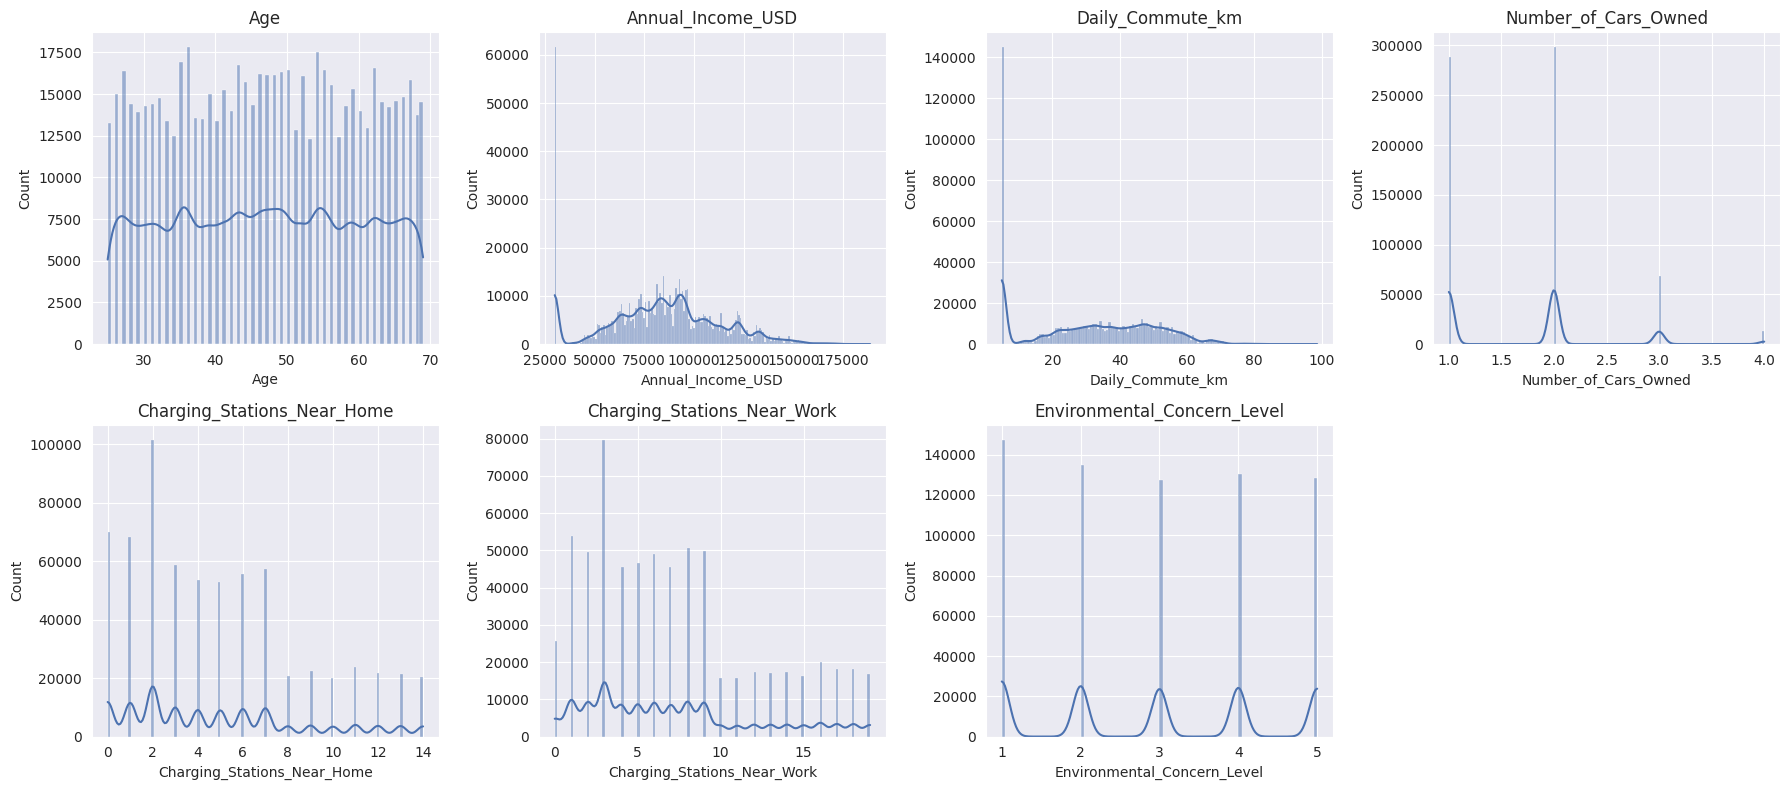

In [6]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
for ax, col in zip(axes.flatten(), num_cols):
    sns.histplot(train[col], kde=True, ax=ax, color='#4C72B0')
    ax.set_title(col)
axes.flatten()[-1].axis('off')
plt.tight_layout()
plt.show()


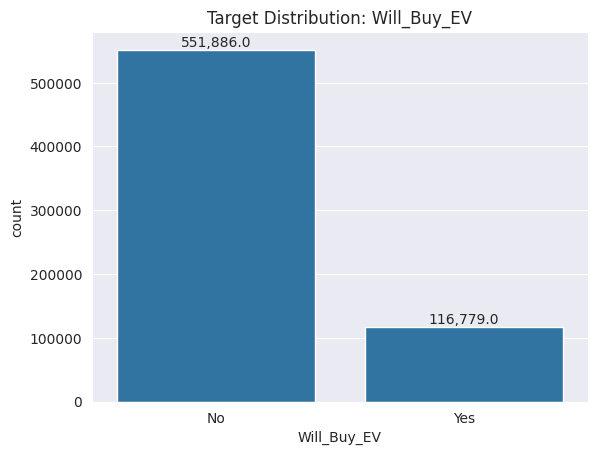

Will_Buy_EV
No     0.825355
Yes    0.174645
Name: proportion, dtype: float64


In [7]:
ax = sns.countplot(x=train['Will_Buy_EV'])
ax.set_title('Target Distribution: Will_Buy_EV')
for p in ax.patches:
    ax.annotate(f'{p.get_height():,}', (p.get_x() + p.get_width()/2, p.get_height()),
                ha='center', va='bottom')
plt.show()

print(train['Will_Buy_EV'].value_counts(normalize=True))


**ملاحظة:** الفئات غير متوازنة (حوالي 82.5% "No" مقابل 17.5% "Yes")، لذلك الاعتماد على الدقة (Accuracy) وحدها غير كافٍ، وسنركز أيضاً على Precision وRecall وF1-score لفئة "Yes".

## ✂️ الخطوة 5: تقسيم البيانات (Data Splitting)
نقسّم بيانات التدريب إلى تدريب/تحقق (80%/20%) مع الحفاظ على نسبة الفئات (`stratify`)، **قبل** أي تقييس للميزات لتفادي تسريب البيانات (Data Leakage).

In [8]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(X_train.shape, X_val.shape)


(534932, 13) (133733, 13)


## ⚖️ الخطوة 6: تقييس الميزات (Feature Scaling)
نستخدم `StandardScaler` ونقوم بعملية الـ `fit` على بيانات التدريب فقط، ثم `transform` على التحقق والاختبار.

In [9]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test_final)


## 🧠 الخطوة 7: بناء وتدريب نموذج LDA (Model Training)

In [10]:
lda = LinearDiscriminantAnalysis()
lda.fit(X_train_scaled, y_train)


,"solver solver: {'svd', 'lsqr', 'eigen'}, default='svd'Solver to use, possible values: - 'svd': Singular value decomposition (default). Does not compute the covariance matrix, therefore this solver is recommended for data with a large number of features. - 'lsqr': Least squares solution. Can be combined with shrinkage or custom covariance estimator. - 'eigen': Eigenvalue decomposition. Can be combined with shrinkage or custom covariance estimator... versionchanged:: 1.2 `solver=""svd""` now has experimental Array API support. See the :ref:`Array API User Guide ` for more details.",'svd'
,"shrinkage shrinkage: 'auto' or float, default=NoneShrinkage parameter, possible values: - None: no shrinkage (default). - 'auto': automatic shrinkage using the Ledoit-Wolf lemma. - float between 0 and 1: fixed shrinkage parameter.This should be left to None if `covariance_estimator` is used.Note that shrinkage works only with 'lsqr' and 'eigen' solvers.For a usage example, see:ref:`sphx_glr_auto_examples_classification_plot_lda.py`.",None
,"priors priors: array-like of shape (n_classes,), default=NoneThe class prior probabilities. By default, the class proportions areinferred from the training data.",None
,"n_components n_components: int, default=NoneNumber of components (<= min(n_classes - 1, n_features)) fordimensionality reduction. If None, will be set tomin(n_classes - 1, n_features). This parameter only affects the`transform` method.For a usage example, see:ref:`sphx_glr_auto_examples_decomposition_plot_pca_vs_lda.py`.",None
,"store_covariance store_covariance: bool, default=FalseIf True, explicitly compute the weighted within-class covariancematrix when solver is 'svd'. The matrix is always computedand stored for the other solvers... versionadded:: 0.17",False
,"tol tol: float, default=1.0e-4Absolute threshold for a singular value of X to be consideredsignificant, used to estimate the rank of X. Dimensions whosesingular values are non-significant are discarded. Only used ifsolver is 'svd'... versionadded:: 0.17",0.0001
,"covariance_estimator covariance_estimator: covariance estimator, default=NoneIf not None, `covariance_estimator` is used to estimatethe covariance matrices instead of relying on the empiricalcovariance estimator (with potential shrinkage).The object should have a fit method and a ``covariance_`` attributelike the estimators in :mod:`sklearn.covariance`.if None the shrinkage parameter drives the estimate.This should be left to None if `shrinkage` is used.Note that `covariance_estimator` works only with 'lsqr' and 'eigen'solvers... versionadded:: 0.24",None


## 🔮 الخطوة 8: التنبؤ (Making Predictions)

In [11]:
y_pred = lda.predict(X_val_scaled)
y_proba = lda.predict_proba(X_val_scaled)[:, 1]


## 📉 الخطوة 9: تقييم الأداء (Model Evaluation)

Accuracy: 0.8938


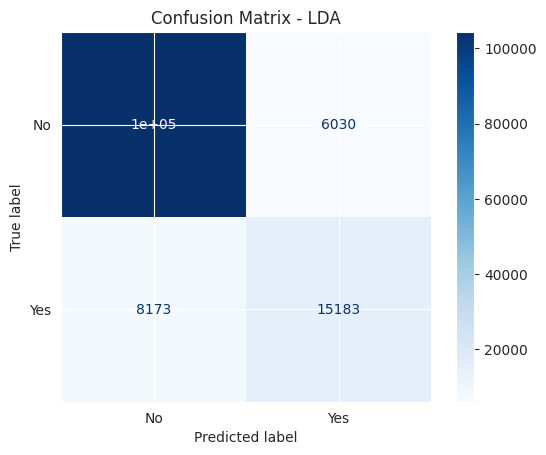

              precision    recall  f1-score   support

          No       0.93      0.95      0.94    110377
         Yes       0.72      0.65      0.68     23356

    accuracy                           0.89    133733
   macro avg       0.82      0.80      0.81    133733
weighted avg       0.89      0.89      0.89    133733



In [12]:
acc = accuracy_score(y_val, y_pred)
print(f"Accuracy: {acc:.4f}")

cm = confusion_matrix(y_val, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le_target.classes_)
disp.plot(cmap='Blues')
plt.title('Confusion Matrix - LDA')
plt.show()

print(classification_report(y_val, y_pred, target_names=le_target.classes_))


/tmp/ipykernel_173/1886641525.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=coef_df, x='Coefficient', y='Feature', palette='coolwarm')


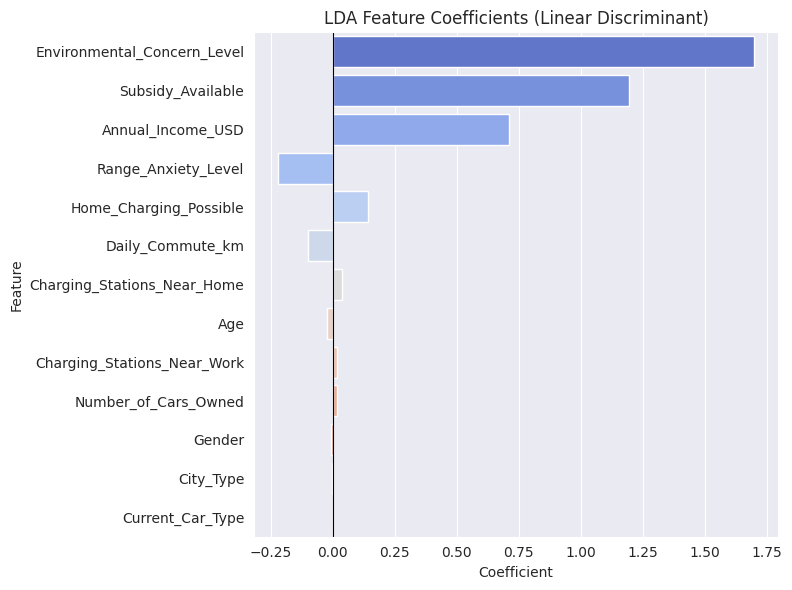

,Feature,Coefficient
6,Environmental_Concern_Level,1.700236
11,Subsidy_Available,1.193478
1,Annual_Income_USD,0.710113
12,Range_Anxiety_Level,-0.220661
10,Home_Charging_Possible,0.143238
2,Daily_Commute_km,-0.098526
4,Charging_Stations_Near_Home,0.037220
0,Age,-0.020722
5,Charging_Stations_Near_Work,0.018901
3,Number_of_Cars_Owned,0.017372


In [13]:
# توزيع معامِلات LDA (Coefficients) - لمعرفة أكثر الميزات تأثيراً على الفصل بين الفئتين
coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': lda.coef_[0]
}).sort_values('Coefficient', key=abs, ascending=False)

plt.figure(figsize=(8, 6))
sns.barplot(data=coef_df, x='Coefficient', y='Feature', palette='coolwarm')
plt.title('LDA Feature Coefficients (Linear Discriminant)')
plt.axvline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

coef_df


## 📝 الخطوة 10: التوثيق والخلاصة (Conclusion & Documentation)

**النتائج:**
- دقة النموذج الإجمالية (Accuracy) على مجموعة التحقق ≈ **89.4%**.
- أداء النموذج على فئة "No" ممتاز (F1 ≈ 0.94)، بينما أداؤه على فئة "Yes" أضعف نسبياً (F1 ≈ 0.68)، وهو أمر متوقع بسبب عدم توازن الفئات (17.5% فقط من العملاء اشتروا سيارة كهربائية).
- نجح LDA في رسم حد فاصل خطي معقول بين الفئتين، مما يشير إلى أن البيانات قابلة للفصل خطياً إلى حد كبير، لكنها ليست مفصولة تماماً — هناك تداخل بين الفئتين في بعض المناطق.

**اقتراحات للتحسين مستقبلاً:**
- تجربة موازنة الفئات (Class Weighting أو SMOTE) لتحسين Recall لفئة "Yes".
- تجربة نماذج غير خطية (Random Forest, XGBoost) للمقارنة مع LDA.
- هندسة ميزات إضافية (Feature Engineering) مثل نسبة الدخل إلى مسافة التنقل اليومي.

## 📤 إضافة: توليد ملف التنبؤ النهائي (Submission) - LDA

In [14]:
test_proba = lda.predict_proba(X_test_scaled)[:, 1]

submission = pd.DataFrame({
    'id': test['id'],
    'Will_Buy_EV': test_proba
})
submission.to_csv('submission.csv', index=False)
submission.head()


,id,Will_Buy_EV
0,668665,0.038158
1,668666,0.183731
2,668667,0.038422
3,668668,0.021901
4,668669,0.030905


## 🔥 مقارنة إضافية: شبكة عصبية بـ PyTorch مع Adam Optimizer
نجرب هل شبكة عصبية بسيطة تقدر تتفوق على LDA في الدقة، باستخدام نفس البيانات المُقيَّسة (`X_train_scaled`, `X_val_scaled`) عشان تكون المقارنة عادلة.

In [15]:
import torch
import torch.nn as nn

def seed_everything(seed=42):
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

seed_everything(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Device:", device)


Device: cpu


### تجهيز البيانات كـ Tensors

In [16]:
X_train_t = torch.tensor(X_train_scaled, dtype=torch.float32).to(device)
y_train_t = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1).to(device)
X_val_t = torch.tensor(X_val_scaled, dtype=torch.float32).to(device)
y_val_t = torch.tensor(y_val, dtype=torch.float32).unsqueeze(1).to(device)
X_test_t = torch.tensor(X_test_scaled, dtype=torch.float32).to(device)


### بناء الموديل `Simplenn`

In [17]:
class Simplenn(nn.Module):
    def __init__(self, input_dim, h1=128, h2=64):
        super(Simplenn, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, h1), nn.ReLU(), nn.Dropout(0.2),
            nn.Linear(h1, h2), nn.ReLU(),
            nn.Linear(h2, 1)  # logits (بدون sigmoid - هنستخدم BCEWithLogitsLoss)
        )

    def forward(self, x):
        return self.net(x)

seed_everything(42)
model = Simplenn(input_dim=X_train_scaled.shape[1]).to(device)
model


Simplenn(
  (net): Sequential(
    (0): Linear(in_features=13, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=128, out_features=64, bias=True)
    (4): ReLU()
    (5): Linear(in_features=64, out_features=1, bias=True)
  )
)

### دالة التدريب `traing_model` مع Adam

In [18]:
def traing_model(model, optimizer, criterion, X_train_t, y_train_t, X_val_t, y_val_t,
                  epochs=50, batch_size=2048, scheduler=None, verbose_every=10):
    n = X_train_t.shape[0]
    for epoch in range(epochs):
        model.train()
        perm = torch.randperm(n)
        total_loss = 0.0
        for i in range(0, n, batch_size):
            idx = perm[i:i + batch_size]
            xb, yb = X_train_t[idx], y_train_t[idx]
            optimizer.zero_grad()
            out = model(xb)
            loss = criterion(out, yb)
            loss.backward()
            optimizer.step()
            total_loss += loss.item() * xb.size(0)
        if scheduler is not None:
            scheduler.step()

        if (epoch + 1) % verbose_every == 0 or epoch == 0:
            model.eval()
            with torch.no_grad():
                val_loss = criterion(model(X_val_t), y_val_t).item()
            print(f"Epoch {epoch+1}/{epochs} - train_loss: {total_loss/n:.4f} - val_loss: {val_loss:.4f}")
    return model

criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=20, gamma=0.5)

model = traing_model(model, optimizer, criterion, X_train_t, y_train_t, X_val_t, y_val_t,
                      epochs=50, batch_size=2048, scheduler=scheduler)


Epoch 1/50 - train_loss: 0.2746 - val_loss: 0.2346


Epoch 10/50 - train_loss: 0.2332 - val_loss: 0.2324


Epoch 20/50 - train_loss: 0.2326 - val_loss: 0.2322


Epoch 30/50 - train_loss: 0.2322 - val_loss: 0.2322


Epoch 40/50 - train_loss: 0.2320 - val_loss: 0.2321


Epoch 50/50 - train_loss: 0.2317 - val_loss: 0.2320


### تقييم شبكة PyTorch ومقارنتها بـ LDA

PyTorch NN Accuracy: 0.8951   |   LDA Accuracy: 0.8938


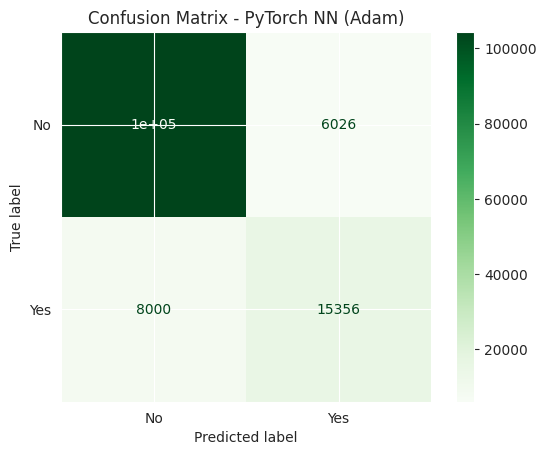

              precision    recall  f1-score   support

          No       0.93      0.95      0.94    110377
         Yes       0.72      0.66      0.69     23356

    accuracy                           0.90    133733
   macro avg       0.82      0.80      0.81    133733
weighted avg       0.89      0.90      0.89    133733



In [19]:
model.eval()
with torch.no_grad():
    val_logits = model(X_val_t)
    val_proba_nn = torch.sigmoid(val_logits).cpu().numpy().flatten()
    val_pred_nn = (val_proba_nn >= 0.5).astype(int)

acc_nn = accuracy_score(y_val, val_pred_nn)
print(f"PyTorch NN Accuracy: {acc_nn:.4f}   |   LDA Accuracy: {acc:.4f}")

cm_nn = confusion_matrix(y_val, val_pred_nn)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_nn, display_labels=le_target.classes_)
disp.plot(cmap='Greens')
plt.title('Confusion Matrix - PyTorch NN (Adam)')
plt.show()

print(classification_report(y_val, val_pred_nn, target_names=le_target.classes_))


**النتيجة:** الشبكة العصبية بتحقق دقة قريبة جداً من LDA (فرق أقل من نصف نقطة مئوية)، وده معناه إن البيانات وصلت لحد أقصى تقريبي في قابلية الفصل (~89-90%) بغض النظر عن تعقيد الموديل. التحسن البسيط ده متوقع لأن العلاقة بين الميزات والهدف قريبة من الخطية أصلاً، وهو نفس اللي كان لاحظه LDA. لو عايزين قفزة حقيقية في الدقة، الحل مش موديل أعقد، لكن **هندسة ميزات جديدة** (Feature Engineering) أو **بيانات إضافية**.

### توليد submission من شبكة PyTorch

In [20]:
with torch.no_grad():
    test_logits = model(X_test_t)
    test_proba_nn = torch.sigmoid(test_logits).cpu().numpy().flatten()

submission_nn = pd.DataFrame({
    'id': test['id'],
    'Will_Buy_EV': test_proba_nn
})
submission_nn.to_csv('submission_nn.csv', index=False)
submission_nn.head()


,id,Will_Buy_EV
0,668665,0.004924
1,668666,0.021820
2,668667,0.004999
3,668668,0.003654
4,668669,0.013541
